# Step-by-Step Tutorial: Ensemble Learning in scikit-learn

This notebook introduces four important ensemble learning methods:

1. **Majority vote**
2. **Averaging**
3. **Stacking**
4. **Bagging**

The notebook only uses ensemble methods that are directly supported in `scikit-learn`.

## Learning objectives

By the end of this tutorial, students should be able to:

1. Explain the general idea of ensemble learning.
2. Use majority voting for classification.
3. Use averaging for regression.
4. Explain the difference between hard voting and soft voting.
5. Build a stacking classifier and stacking regressor.
6. Build a bagging classifier and bagging regressor.
7. Compare ensemble models with individual base models.
8. Understand when different ensemble methods are useful.

## Required libraries

This notebook uses:

- `numpy`
- `pandas`
- `matplotlib`
- `scikit-learn`

## 1. What is ensemble learning?

**Ensemble learning** combines multiple models to produce one final prediction.

The motivation is simple:

> Several models together can often perform better than one model alone.

A single model may make errors because:

- it is too simple,
- it is too sensitive to noise,
- it overfits the training data,
- it captures only one type of pattern.

An ensemble combines multiple models so that their weaknesses can be balanced.

## Four methods in this notebook

| Method | Main idea | scikit-learn class |
|---|---|---|
| Majority vote | Several classifiers vote for the final class | `VotingClassifier` |
| Averaging | Several regressors produce numeric predictions, then predictions are averaged | `VotingRegressor` |
| Stacking | A meta-model learns how to combine base models | `StackingClassifier`, `StackingRegressor` |
| Bagging | Many models are trained on bootstrap samples | `BaggingClassifier`, `BaggingRegressor` |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_regression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR

from sklearn.ensemble import (
    VotingClassifier,
    VotingRegressor,
    StackingClassifier,
    StackingRegressor,
    BaggingClassifier,
    BaggingRegressor,
    RandomForestClassifier,
    RandomForestRegressor
)

RANDOM_STATE = 42

## 2. Helper functions

We define helper functions for:

1. plotting decision boundaries for classification,
2. evaluating classifiers,
3. evaluating regressors.

In [2]:
def plot_decision_boundary(model, X, y, title):
    # Plot a 2D decision boundary for a fitted classifier.
    x_min, x_max = X[:, 0].min() - 0.7, X[:, 0].max() + 0.7
    y_min, y_max = X[:, 1].min() - 0.7, X[:, 1].max() + 0.7

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    predictions = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, predictions, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="black", alpha=0.8)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.grid(True)
    plt.show()


def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    result = {
        "model": model_name,
        "train_accuracy": model.score(X_train, y_train),
        "test_accuracy": accuracy_score(y_test, y_pred)
    }

    return result


def evaluate_regressor(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    result = {
        "model": model_name,
        "train_r2": model.score(X_train, y_train),
        "test_r2": r2_score(y_test, y_pred),
        "test_mae": mean_absolute_error(y_test, y_pred),
        "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred))
    }

    return result

# Part A: Majority Vote for Classification

## 3. Majority vote

Majority voting is used for classification.

Suppose three classifiers predict:

| Model | Prediction |
|---|---|
| Logistic Regression | Class 1 |
| kNN | Class 1 |
| Decision Tree | Class 0 |

The final majority-vote prediction is:

$$
\text{Class 1}
$$

because class 1 receives two votes.

In `scikit-learn`, majority voting is implemented by:

```python
VotingClassifier(voting="hard")
```

This is called **hard voting** because each model votes for a class label.

## 4. Create a classification dataset

We use a two-dimensional moon-shaped dataset because it is nonlinear and easy to visualize.

In [3]:
X_clf, y_clf = make_moons(
    n_samples=500,
    noise=0.30,
    random_state=RANDOM_STATE
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

print("Training shape:", X_train_clf.shape)
print("Test shape:", X_test_clf.shape)

Training shape: (350, 2)
Test shape: (150, 2)


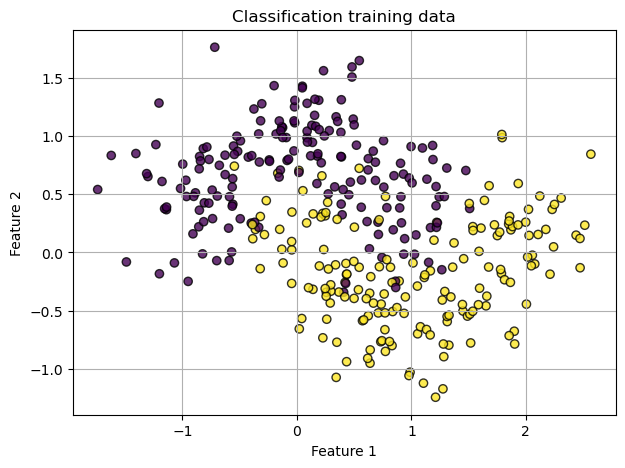

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(X_train_clf[:, 0], X_train_clf[:, 1], c=y_train_clf, edgecolor="black", alpha=0.8)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Classification training data")
plt.grid(True)
plt.show()

## 5. Train individual base classifiers

We use three different classifiers:

1. Logistic Regression
2. k-Nearest Neighbors
3. Decision Tree

The models are intentionally different. This is useful because an ensemble benefits from diversity.

In [5]:
clf_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=RANDOM_STATE))
])

clf_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=9))
])

clf_tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=RANDOM_STATE
)

base_classifiers = [
    ("Logistic Regression", clf_logistic),
    ("kNN", clf_knn),
    ("Decision Tree", clf_tree)
]

base_clf_results = []

for name, model in base_classifiers:
    result = evaluate_classifier(
        model,
        X_train_clf,
        X_test_clf,
        y_train_clf,
        y_test_clf,
        name
    )
    base_clf_results.append(result)

pd.DataFrame(base_clf_results)

,model,train_accuracy,test_accuracy
0,Logistic Regression,0.854286,0.826667
1,kNN,0.920000,0.906667
2,Decision Tree,0.905714,0.880000


## 6. Hard voting with VotingClassifier

Now we combine the three classifiers using majority voting.

Important:

- `voting="hard"` means majority vote over class labels.
- Each model has one vote.

In [6]:
hard_voting_clf = VotingClassifier(
    estimators=[
        ("logistic", clf_logistic),
        ("knn", clf_knn),
        ("tree", clf_tree)
    ],
    voting="hard"
)

hard_voting_result = evaluate_classifier(
    hard_voting_clf,
    X_train_clf,
    X_test_clf,
    y_train_clf,
    y_test_clf,
    "Hard Voting Classifier"
)

pd.DataFrame(base_clf_results + [hard_voting_result])

,model,train_accuracy,test_accuracy
0,Logistic Regression,0.854286,0.826667
1,kNN,0.920000,0.906667
2,Decision Tree,0.905714,0.880000
3,Hard Voting Classifier,0.897143,0.880000


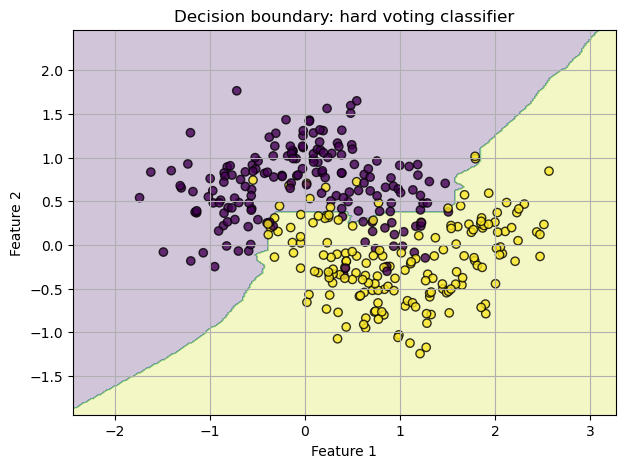

In [7]:
hard_voting_clf.fit(X_train_clf, y_train_clf)
plot_decision_boundary(
    hard_voting_clf,
    X_train_clf,
    y_train_clf,
    "Decision boundary: hard voting classifier"
)

## 7. Soft voting

Soft voting averages predicted class probabilities.

Example:

| Model | Probability of class 1 |
|---|---:|
| Logistic Regression | 0.80 |
| kNN | 0.70 |
| Decision Tree | 0.40 |

Average probability:

$$
\frac{0.80 + 0.70 + 0.40}{3} = 0.633
$$

If the threshold is 0.5, the final prediction is class 1.

In `scikit-learn`:

```python
VotingClassifier(voting="soft")
```

Soft voting requires base classifiers that support `predict_proba`.

In [8]:
soft_voting_clf = VotingClassifier(
    estimators=[
        ("logistic", clf_logistic),
        ("knn", clf_knn),
        ("tree", clf_tree)
    ],
    voting="soft"
)

soft_voting_result = evaluate_classifier(
    soft_voting_clf,
    X_train_clf,
    X_test_clf,
    y_train_clf,
    y_test_clf,
    "Soft Voting Classifier"
)

pd.DataFrame(base_clf_results + [hard_voting_result, soft_voting_result])

,model,train_accuracy,test_accuracy
0,Logistic Regression,0.854286,0.826667
1,kNN,0.920000,0.906667
2,Decision Tree,0.905714,0.880000
3,Hard Voting Classifier,0.897143,0.880000
4,Soft Voting Classifier,0.908571,0.893333


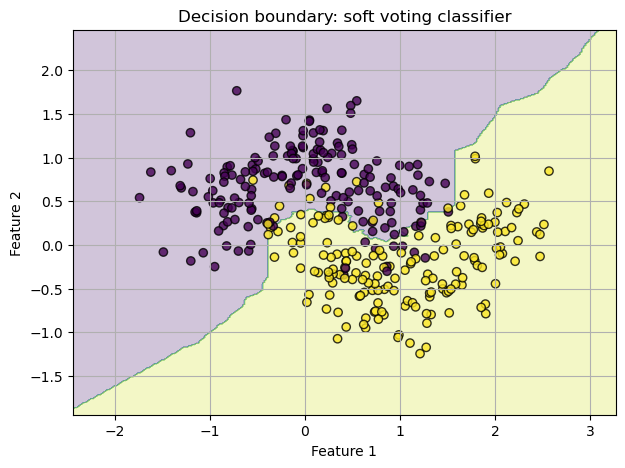

In [9]:
soft_voting_clf.fit(X_train_clf, y_train_clf)
plot_decision_boundary(
    soft_voting_clf,
    X_train_clf,
    y_train_clf,
    "Decision boundary: soft voting classifier"
)

## 8. Weighted voting

Sometimes some models are more reliable than others.

We can give them larger weights.

Example:

```python
weights=[2, 1, 1]
```

This means the first model has twice as much influence as the others.

In [10]:
weighted_soft_voting_clf = VotingClassifier(
    estimators=[
        ("logistic", clf_logistic),
        ("knn", clf_knn),
        ("tree", clf_tree)
    ],
    voting="soft",
    weights=[1, 2, 1]
)

weighted_soft_voting_result = evaluate_classifier(
    weighted_soft_voting_clf,
    X_train_clf,
    X_test_clf,
    y_train_clf,
    y_test_clf,
    "Weighted Soft Voting Classifier"
)

pd.DataFrame(base_clf_results + [
    hard_voting_result,
    soft_voting_result,
    weighted_soft_voting_result
])

,model,train_accuracy,test_accuracy
0,Logistic Regression,0.854286,0.826667
1,kNN,0.920000,0.906667
2,Decision Tree,0.905714,0.880000
3,Hard Voting Classifier,0.897143,0.880000
4,Soft Voting Classifier,0.908571,0.893333
5,Weighted Soft Voting Classifier,0.914286,0.900000


# Part B: Averaging for Regression

## 9. Averaging

Averaging is commonly used for regression.

Suppose three regressors predict a house price:

| Model | Prediction |
|---|---:|
| Linear Regression | 300,000 |
| kNN Regressor | 320,000 |
| Decision Tree Regressor | 310,000 |

The average prediction is:

$$
\frac{300000 + 320000 + 310000}{3} = 310000
$$

In `scikit-learn`, averaging for regression is implemented by:

```python
VotingRegressor
```

Although the name says "Voting", for regression it averages numeric predictions.

## 10. Create a regression dataset

In [11]:
X_reg, y_reg = make_regression(
    n_samples=600,
    n_features=8,
    n_informative=5,
    noise=25,
    random_state=RANDOM_STATE
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.30,
    random_state=RANDOM_STATE
)

print("Training shape:", X_train_reg.shape)
print("Test shape:", X_test_reg.shape)

Training shape: (420, 8)
Test shape: (180, 8)


## 11. Train individual base regressors

We use:

1. Linear Regression
2. kNN Regressor
3. Decision Tree Regressor

In [12]:
reg_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

reg_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=9))
])

reg_tree = DecisionTreeRegressor(
    max_depth=5,
    random_state=RANDOM_STATE
)

base_regressors = [
    ("Linear Regression", reg_linear),
    ("kNN Regressor", reg_knn),
    ("Decision Tree Regressor", reg_tree)
]

base_reg_results = []

for name, model in base_regressors:
    result = evaluate_regressor(
        model,
        X_train_reg,
        X_test_reg,
        y_train_reg,
        y_test_reg,
        name
    )
    base_reg_results.append(result)

pd.DataFrame(base_reg_results)

,model,train_r2,test_r2,test_mae,test_rmse
0,Linear Regression,0.959801,0.955496,19.868142,25.215703
1,kNN Regressor,0.790238,0.763075,45.836671,58.180510
2,Decision Tree Regressor,0.871531,0.665475,52.228508,69.133126


## 12. Averaging with VotingRegressor

Now we combine the regressors by averaging their predictions.

In [13]:
averaging_regressor = VotingRegressor(
    estimators=[
        ("linear", reg_linear),
        ("knn", reg_knn),
        ("tree", reg_tree)
    ]
)

averaging_result = evaluate_regressor(
    averaging_regressor,
    X_train_reg,
    X_test_reg,
    y_train_reg,
    y_test_reg,
    "VotingRegressor Averaging"
)

pd.DataFrame(base_reg_results + [averaging_result])

,model,train_r2,test_r2,test_mae,test_rmse
0,Linear Regression,0.959801,0.955496,19.868142,25.215703
1,kNN Regressor,0.790238,0.763075,45.836671,58.180510
2,Decision Tree Regressor,0.871531,0.665475,52.228508,69.133126
3,VotingRegressor Averaging,0.930333,0.897762,29.840683,38.218786


## 13. Visualize predicted vs true values

A good regression model should produce points close to the diagonal line.

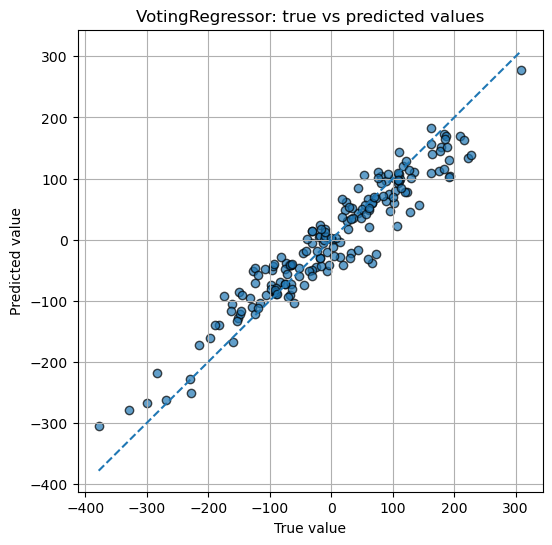

In [14]:
averaging_regressor.fit(X_train_reg, y_train_reg)
y_pred_avg = averaging_regressor.predict(X_test_reg)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_avg, alpha=0.7, edgecolor="black")
min_value = min(y_test_reg.min(), y_pred_avg.min())
max_value = max(y_test_reg.max(), y_pred_avg.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xlabel("True value")
plt.ylabel("Predicted value")
plt.title("VotingRegressor: true vs predicted values")
plt.grid(True)
plt.show()

# Part C: Stacking

## 14. What is stacking?

Stacking trains multiple base models and then trains a final model to combine them.

The final model is often called:

- meta-model,
- meta-learner,
- final estimator.

The idea:

1. Train several base models.
2. Use their predictions as new features.
3. Train a final model on those prediction features.

In `scikit-learn`, stacking uses cross-validation internally to generate out-of-fold predictions for the final estimator. This reduces overfitting in the meta-model.

Supported classes:

```python
StackingClassifier
StackingRegressor
```

## 15. StackingClassifier

We now create a stacking classifier.

Base models:

1. Logistic Regression
2. kNN
3. Decision Tree

Final estimator:

- Logistic Regression

In [15]:
stacking_clf = StackingClassifier(
    estimators=[
        ("logistic", clf_logistic),
        ("knn", clf_knn),
        ("tree", clf_tree)
    ],
    final_estimator=LogisticRegression(random_state=RANDOM_STATE),
    cv=5
)

stacking_clf_result = evaluate_classifier(
    stacking_clf,
    X_train_clf,
    X_test_clf,
    y_train_clf,
    y_test_clf,
    "Stacking Classifier"
)

pd.DataFrame(base_clf_results + [
    hard_voting_result,
    soft_voting_result,
    weighted_soft_voting_result,
    stacking_clf_result
])

,model,train_accuracy,test_accuracy
0,Logistic Regression,0.854286,0.826667
1,kNN,0.920000,0.906667
2,Decision Tree,0.905714,0.880000
3,Hard Voting Classifier,0.897143,0.880000
4,Soft Voting Classifier,0.908571,0.893333
5,Weighted Soft Voting Classifier,0.914286,0.900000
6,Stacking Classifier,0.914286,0.906667


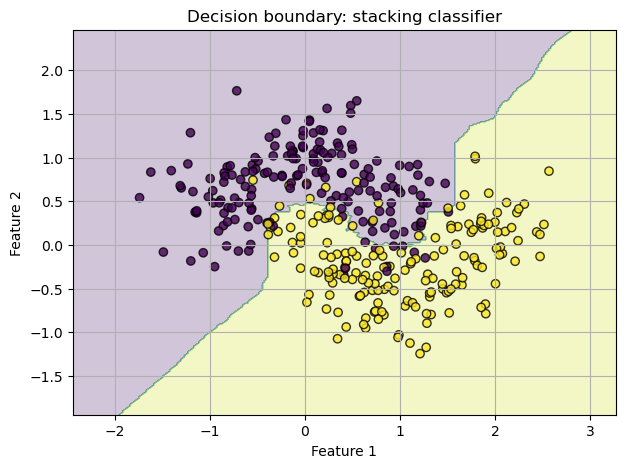

In [16]:
stacking_clf.fit(X_train_clf, y_train_clf)

plot_decision_boundary(
    stacking_clf,
    X_train_clf,
    y_train_clf,
    "Decision boundary: stacking classifier"
)

## 16. StackingRegressor

Now we create a stacking regressor.

Base models:

1. Linear Regression
2. kNN Regressor
3. Decision Tree Regressor

Final estimator:

- Ridge Regression

In [17]:
stacking_reg = StackingRegressor(
    estimators=[
        ("linear", reg_linear),
        ("knn", reg_knn),
        ("tree", reg_tree)
    ],
    final_estimator=Ridge(),
    cv=5
)

stacking_reg_result = evaluate_regressor(
    stacking_reg,
    X_train_reg,
    X_test_reg,
    y_train_reg,
    y_test_reg,
    "Stacking Regressor"
)

pd.DataFrame(base_reg_results + [
    averaging_result,
    stacking_reg_result
])

,model,train_r2,test_r2,test_mae,test_rmse
0,Linear Regression,0.959801,0.955496,19.868142,25.215703
1,kNN Regressor,0.790238,0.763075,45.836671,58.180510
2,Decision Tree Regressor,0.871531,0.665475,52.228508,69.133126
3,VotingRegressor Averaging,0.930333,0.897762,29.840683,38.218786
4,Stacking Regressor,0.960823,0.955131,19.932138,25.318928


## 17. Inspect stacking predictions

The stacking model learns how to combine the base models. It does not simply average them.

This can help when different base models are good in different regions of the data.

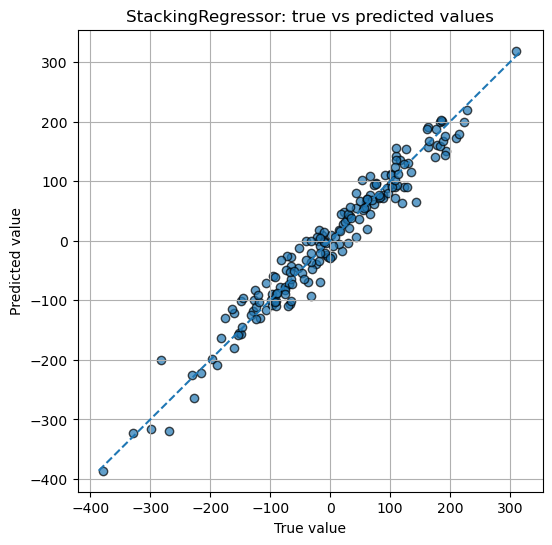

In [18]:
stacking_reg.fit(X_train_reg, y_train_reg)
y_pred_stack = stacking_reg.predict(X_test_reg)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_stack, alpha=0.7, edgecolor="black")
min_value = min(y_test_reg.min(), y_pred_stack.min())
max_value = max(y_test_reg.max(), y_pred_stack.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xlabel("True value")
plt.ylabel("Predicted value")
plt.title("StackingRegressor: true vs predicted values")
plt.grid(True)
plt.show()

# Part D: Bagging

## 18. What is bagging?

Bagging means **bootstrap aggregation**.

The steps are:

1. Create many bootstrap samples from the training data.
2. Train one base model on each bootstrap sample.
3. Combine predictions.

For classification:

\[
\text{final prediction} = \text{majority vote}
\]

For regression:

\[
\text{final prediction} = \text{average prediction}
\]

Bagging is useful because it reduces variance.

It works especially well with high-variance models such as decision trees.

## 19. BaggingClassifier

In `scikit-learn`, bagging for classification is implemented with:

```python
BaggingClassifier
```

We use a decision tree as the base estimator.

In [19]:
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    n_estimators=100,
    max_samples=0.8,
    bootstrap=True,
    oob_score=True,
    random_state=RANDOM_STATE
)

bagging_clf_result = evaluate_classifier(
    bagging_clf,
    X_train_clf,
    X_test_clf,
    y_train_clf,
    y_test_clf,
    "Bagging Classifier"
)

bagging_clf.fit(X_train_clf, y_train_clf)

print("Out-of-bag score:", bagging_clf.oob_score_)

pd.DataFrame(base_clf_results + [
    hard_voting_result,
    soft_voting_result,
    weighted_soft_voting_result,
    stacking_clf_result,
    bagging_clf_result
])

Out-of-bag score: 0.8914285714285715


,model,train_accuracy,test_accuracy
0,Logistic Regression,0.854286,0.826667
1,kNN,0.920000,0.906667
2,Decision Tree,0.905714,0.880000
3,Hard Voting Classifier,0.897143,0.880000
4,Soft Voting Classifier,0.908571,0.893333
5,Weighted Soft Voting Classifier,0.914286,0.900000
6,Stacking Classifier,0.914286,0.906667
7,Bagging Classifier,1.000000,0.906667


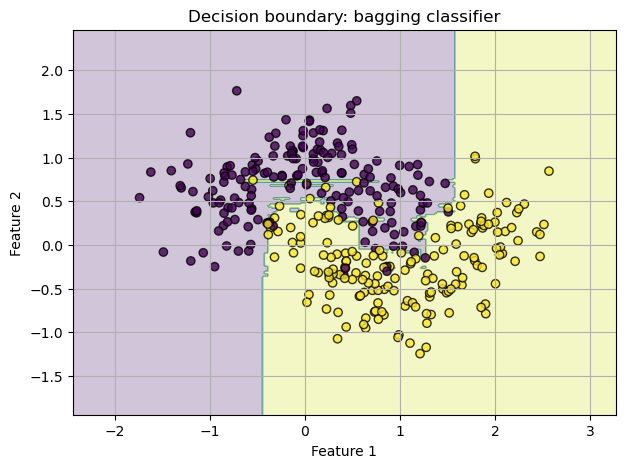

In [20]:
plot_decision_boundary(
    bagging_clf,
    X_train_clf,
    y_train_clf,
    "Decision boundary: bagging classifier"
)

## 20. BaggingRegressor

In `scikit-learn`, bagging for regression is implemented with:

```python
BaggingRegressor
```

Again, we use a decision tree as the base estimator.

In [21]:
bagging_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
    n_estimators=100,
    max_samples=0.8,
    bootstrap=True,
    oob_score=True,
    random_state=RANDOM_STATE
)

bagging_reg_result = evaluate_regressor(
    bagging_reg,
    X_train_reg,
    X_test_reg,
    y_train_reg,
    y_test_reg,
    "Bagging Regressor"
)

bagging_reg.fit(X_train_reg, y_train_reg)

print("Out-of-bag score:", bagging_reg.oob_score_)

pd.DataFrame(base_reg_results + [
    averaging_result,
    stacking_reg_result,
    bagging_reg_result
])

Out-of-bag score: 0.853543624089709


,model,train_r2,test_r2,test_mae,test_rmse
0,Linear Regression,0.959801,0.955496,19.868142,25.215703
1,kNN Regressor,0.790238,0.763075,45.836671,58.180510
2,Decision Tree Regressor,0.871531,0.665475,52.228508,69.133126
3,VotingRegressor Averaging,0.930333,0.897762,29.840683,38.218786
4,Stacking Regressor,0.960823,0.955131,19.932138,25.318928
5,Bagging Regressor,0.970020,0.896470,30.723165,38.459527


## 21. Effect of the number of bagging estimators

The parameter `n_estimators` controls the number of models in the bagging ensemble.

Usually:

- More estimators make the result more stable.
- Training time increases.
- Performance often improves at first, then becomes stable.

In [22]:
n_estimators_values = [1, 5, 10, 25, 50, 100, 200]
bagging_size_results = []

for n_estimators in n_estimators_values:
    model = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=n_estimators,
        max_samples=0.8,
        bootstrap=True,
        oob_score=True if n_estimators >= 10 else False,
        random_state=RANDOM_STATE
    )

    model.fit(X_train_clf, y_train_clf)

    row = {
        "n_estimators": n_estimators,
        "train_accuracy": model.score(X_train_clf, y_train_clf),
        "test_accuracy": model.score(X_test_clf, y_test_clf),
        "oob_score": model.oob_score_ if n_estimators >= 10 else np.nan
    }

    bagging_size_results.append(row)

bagging_size_df = pd.DataFrame(bagging_size_results)
bagging_size_df

,n_estimators,train_accuracy,test_accuracy,oob_score
0,1,0.942857,0.846667,NaN
1,5,0.971429,0.880000,NaN
2,10,0.980000,0.873333,0.891429
3,25,0.991429,0.906667,0.900000
4,50,0.997143,0.906667,0.888571
5,100,1.000000,0.906667,0.891429
6,200,1.000000,0.906667,0.897143


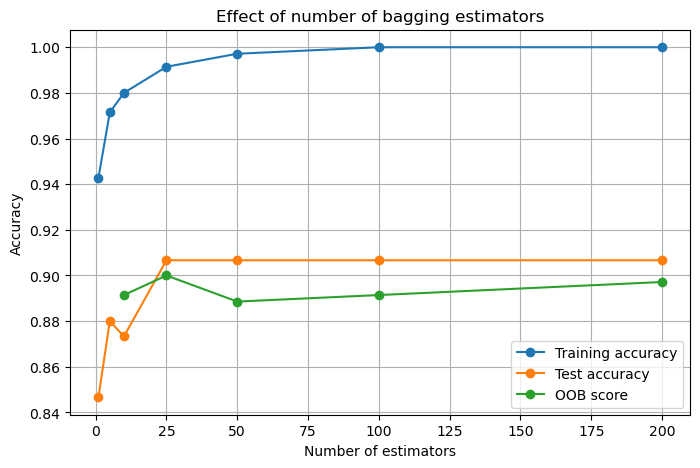

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(bagging_size_df["n_estimators"], bagging_size_df["train_accuracy"], marker="o", label="Training accuracy")
plt.plot(bagging_size_df["n_estimators"], bagging_size_df["test_accuracy"], marker="o", label="Test accuracy")
plt.plot(bagging_size_df["n_estimators"], bagging_size_df["oob_score"], marker="o", label="OOB score")
plt.xlabel("Number of estimators")
plt.ylabel("Accuracy")
plt.title("Effect of number of bagging estimators")
plt.legend()
plt.grid(True)
plt.show()

## 22. Bagging vs Random Forest

Random Forest is closely related to bagging.

A basic bagging classifier with decision trees:

- trains trees on bootstrap samples,
- usually allows each tree to consider all features at each split.

Random Forest:

- trains trees on bootstrap samples,
- additionally considers a random subset of features at each split.

This extra feature randomness makes the trees more diverse.

In `scikit-learn`, Random Forest is implemented separately:

```python
RandomForestClassifier
RandomForestRegressor
```

We include this short comparison because Random Forest is one of the most common bagging-style models.

In [24]:
random_forest_clf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    random_state=RANDOM_STATE
)

rf_clf_result = evaluate_classifier(
    random_forest_clf,
    X_train_clf,
    X_test_clf,
    y_train_clf,
    y_test_clf,
    "Random Forest Classifier"
)

pd.DataFrame(base_clf_results + [
    hard_voting_result,
    soft_voting_result,
    weighted_soft_voting_result,
    stacking_clf_result,
    bagging_clf_result,
    rf_clf_result
])

,model,train_accuracy,test_accuracy
0,Logistic Regression,0.854286,0.826667
1,kNN,0.920000,0.906667
2,Decision Tree,0.905714,0.880000
3,Hard Voting Classifier,0.897143,0.880000
4,Soft Voting Classifier,0.908571,0.893333
5,Weighted Soft Voting Classifier,0.914286,0.900000
6,Stacking Classifier,0.914286,0.906667
7,Bagging Classifier,1.000000,0.906667
8,Random Forest Classifier,1.000000,0.873333


# Part E: Final comparison and practical guidance

## 23. Classification comparison

In [25]:
classification_results = pd.DataFrame(base_clf_results + [
    hard_voting_result,
    soft_voting_result,
    weighted_soft_voting_result,
    stacking_clf_result,
    bagging_clf_result,
    rf_clf_result
]).sort_values("test_accuracy", ascending=False)

classification_results

,model,train_accuracy,test_accuracy
1,kNN,0.920000,0.906667
7,Bagging Classifier,1.000000,0.906667
6,Stacking Classifier,0.914286,0.906667
5,Weighted Soft Voting Classifier,0.914286,0.900000
4,Soft Voting Classifier,0.908571,0.893333
3,Hard Voting Classifier,0.897143,0.880000
2,Decision Tree,0.905714,0.880000
8,Random Forest Classifier,1.000000,0.873333
0,Logistic Regression,0.854286,0.826667


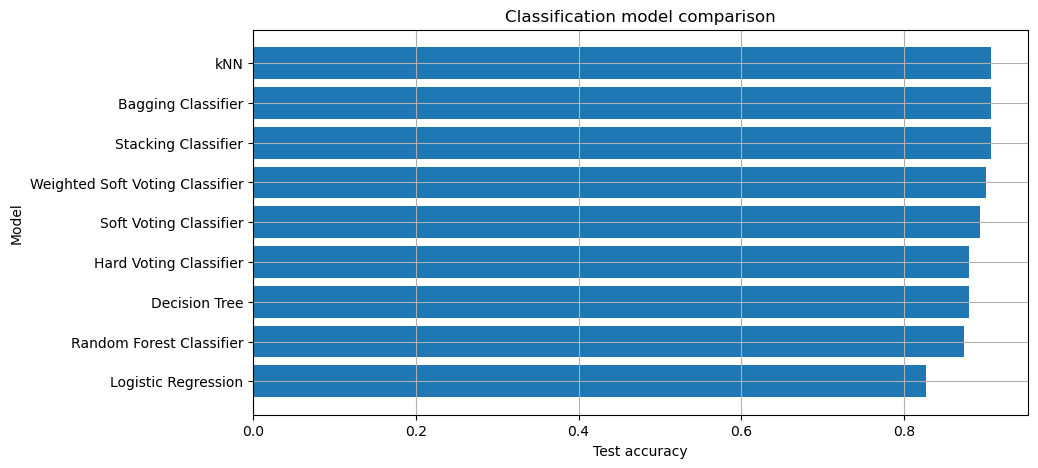

In [26]:
plt.figure(figsize=(10, 5))
plt.barh(classification_results["model"], classification_results["test_accuracy"])
plt.xlabel("Test accuracy")
plt.ylabel("Model")
plt.title("Classification model comparison")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

## 24. Regression comparison

In [27]:
random_forest_reg = RandomForestRegressor(
    n_estimators=100,
    max_features="sqrt",
    random_state=RANDOM_STATE
)

rf_reg_result = evaluate_regressor(
    random_forest_reg,
    X_train_reg,
    X_test_reg,
    y_train_reg,
    y_test_reg,
    "Random Forest Regressor"
)

regression_results = pd.DataFrame(base_reg_results + [
    averaging_result,
    stacking_reg_result,
    bagging_reg_result,
    rf_reg_result
]).sort_values("test_r2", ascending=False)

regression_results

,model,train_r2,test_r2,test_mae,test_rmse
0,Linear Regression,0.959801,0.955496,19.868142,25.215703
4,Stacking Regressor,0.960823,0.955131,19.932138,25.318928
3,VotingRegressor Averaging,0.930333,0.897762,29.840683,38.218786
5,Bagging Regressor,0.970020,0.896470,30.723165,38.459527
6,Random Forest Regressor,0.971615,0.833451,37.693866,48.780029
1,kNN Regressor,0.790238,0.763075,45.836671,58.180510
2,Decision Tree Regressor,0.871531,0.665475,52.228508,69.133126


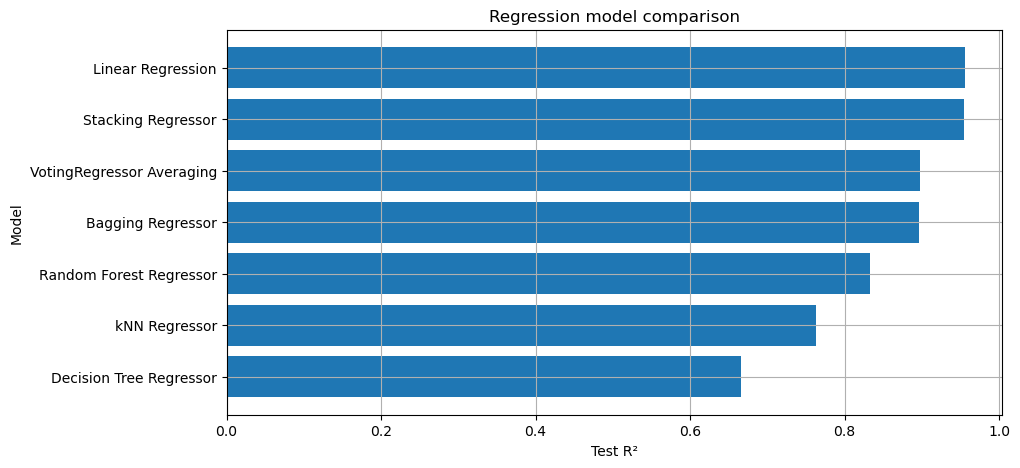

In [28]:
plt.figure(figsize=(10, 5))
plt.barh(regression_results["model"], regression_results["test_r2"])
plt.xlabel("Test R²")
plt.ylabel("Model")
plt.title("Regression model comparison")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

## 25. When should we use each method?

| Method | Best used when | Main risk |
|---|---|---|
| Majority vote | You have several good but different classifiers | Weak models may hurt the ensemble |
| Soft voting | Classifiers provide reliable probabilities | Poorly calibrated probabilities may mislead the ensemble |
| Averaging | You have several reasonable regressors | Bad regressors can pull the average in the wrong direction |
| Stacking | You want a model to learn how to combine other models | Can overfit if not cross-validated carefully |
| Bagging | Base model has high variance, for example decision trees | Less useful for very stable low-variance models |

## Practical advice

1. Start with simple individual models.
2. Use voting or averaging when several models have similar performance.
3. Use stacking when base models make different types of errors.
4. Use bagging for unstable models such as decision trees.
5. Compare with Random Forest as a strong baseline.
6. Use cross-validation before making final conclusions.

## 26. Mini exercises for students

### Classification exercises

1. Change the noise in `make_moons` from `0.30` to `0.10` and `0.50`.
2. Compare hard voting and soft voting.
3. Change the weights in weighted soft voting.
4. Replace the decision tree with an SVM classifier.
5. Try different values of `n_neighbors` in kNN.
6. Tune the stacking classifier using cross-validation.

### Regression exercises

1. Increase the noise in `make_regression`.
2. Replace `LinearRegression` with `Ridge`.
3. Replace the decision tree regressor with `SVR`.
4. Compare `VotingRegressor` and `StackingRegressor`.
5. Increase and decrease the number of bagging estimators.
6. Compare `BaggingRegressor` and `RandomForestRegressor`.

### Reflection questions

1. Why can ensemble learning improve generalization?
2. Why is model diversity important?
3. Why can stacking overfit?
4. Why does bagging reduce variance?
5. Why is Random Forest related to bagging?

## 27. Summary

In this notebook, we studied four ensemble learning methods supported by `scikit-learn`.

### Majority vote

- Used for classification.
- Implemented with `VotingClassifier`.
- Hard voting uses class labels.
- Soft voting averages predicted probabilities.

### Averaging

- Used for regression.
- Implemented with `VotingRegressor`.
- Final prediction is the average of base model predictions.

### Stacking

- Uses a final estimator to learn how to combine base model predictions.
- Implemented with `StackingClassifier` and `StackingRegressor`.

### Bagging

- Trains many base models on bootstrap samples.
- Reduces variance.
- Implemented with `BaggingClassifier` and `BaggingRegressor`.

The key idea of ensemble learning is not just to use many models, but to combine models that make different errors.

## References and further learning

- scikit-learn user guide: Ensemble methods
- scikit-learn documentation: `VotingClassifier`
- scikit-learn documentation: `VotingRegressor`
- scikit-learn documentation: `StackingClassifier`
- scikit-learn documentation: `StackingRegressor`
- scikit-learn documentation: `BaggingClassifier`
- scikit-learn documentation: `BaggingRegressor`
- scikit-learn documentation: `RandomForestClassifier`
- scikit-learn documentation: `RandomForestRegressor`